# 01 — Data Exploration

Load NSE 1-minute OHLCV data, check quality, and visualise raw series.

**Prerequisites**: Place CSV files (NIFTY.csv, BANKNIFTY.csv, HDFCBANK.csv, RELIANCE.csv, INFY.csv) in `../data/raw/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import TICKERS, RAW_DIR
from src.data_loader import load_all_tickers, align_tickers, save_processed

sns.set_style('whitegrid')
%matplotlib inline

## 1.1 Load raw data

In [2]:
data = load_all_tickers()

for ticker, df in data.items():
    print(f"{ticker:12s}  rows={len(df):>8,}  "
          f"from {df.index.min().date()} to {df.index.max().date()}  "
          f"missing_close={df['close'].isna().sum()}")

NIFTY         rows=  98,625  from 2024-01-02 to 2025-01-02  missing_close=0
BANKNIFTY     rows=  98,625  from 2024-01-02 to 2025-01-02  missing_close=0
HDFCBANK      rows=  98,625  from 2024-01-02 to 2025-01-02  missing_close=0
RELIANCE      rows=  98,625  from 2024-01-02 to 2025-01-02  missing_close=0
INFY          rows=  98,625  from 2024-01-02 to 2025-01-02  missing_close=0


## 1.2 Check for gaps and duplicates

In [3]:
for ticker, df in data.items():
    diffs = df.index.to_series().diff().dropna()
    # Expected diff is 1 minute during market hours
    gap_threshold = pd.Timedelta(minutes=5)
    gaps = diffs[diffs > gap_threshold]
    print(f"{ticker}: {len(gaps)} gaps > 5 min")
    if len(gaps) > 0:
        print(gaps.head(5))

NIFTY: 262 gaps > 5 min
datetime
2024-01-03 09:15:00   0 days 17:46:00
2024-01-04 09:15:00   0 days 17:46:00
2024-01-05 09:15:00   0 days 17:46:00
2024-01-08 09:15:00   2 days 17:46:00
2024-01-09 09:15:00   0 days 17:46:00
Name: datetime, dtype: timedelta64[ns]
BANKNIFTY: 262 gaps > 5 min
datetime
2024-01-03 09:15:00   0 days 17:46:00
2024-01-04 09:15:00   0 days 17:46:00
2024-01-05 09:15:00   0 days 17:46:00
2024-01-08 09:15:00   2 days 17:46:00
2024-01-09 09:15:00   0 days 17:46:00
Name: datetime, dtype: timedelta64[ns]
HDFCBANK: 262 gaps > 5 min
datetime
2024-01-03 09:15:00   0 days 17:46:00
2024-01-04 09:15:00   0 days 17:46:00
2024-01-05 09:15:00   0 days 17:46:00
2024-01-08 09:15:00   2 days 17:46:00
2024-01-09 09:15:00   0 days 17:46:00
Name: datetime, dtype: timedelta64[ns]
RELIANCE: 262 gaps > 5 min
datetime
2024-01-03 09:15:00   0 days 17:46:00
2024-01-04 09:15:00   0 days 17:46:00
2024-01-05 09:15:00   0 days 17:46:00
2024-01-08 09:15:00   2 days 17:46:00
2024-01-09 09:15:00

## 1.3 Intraday volume profile

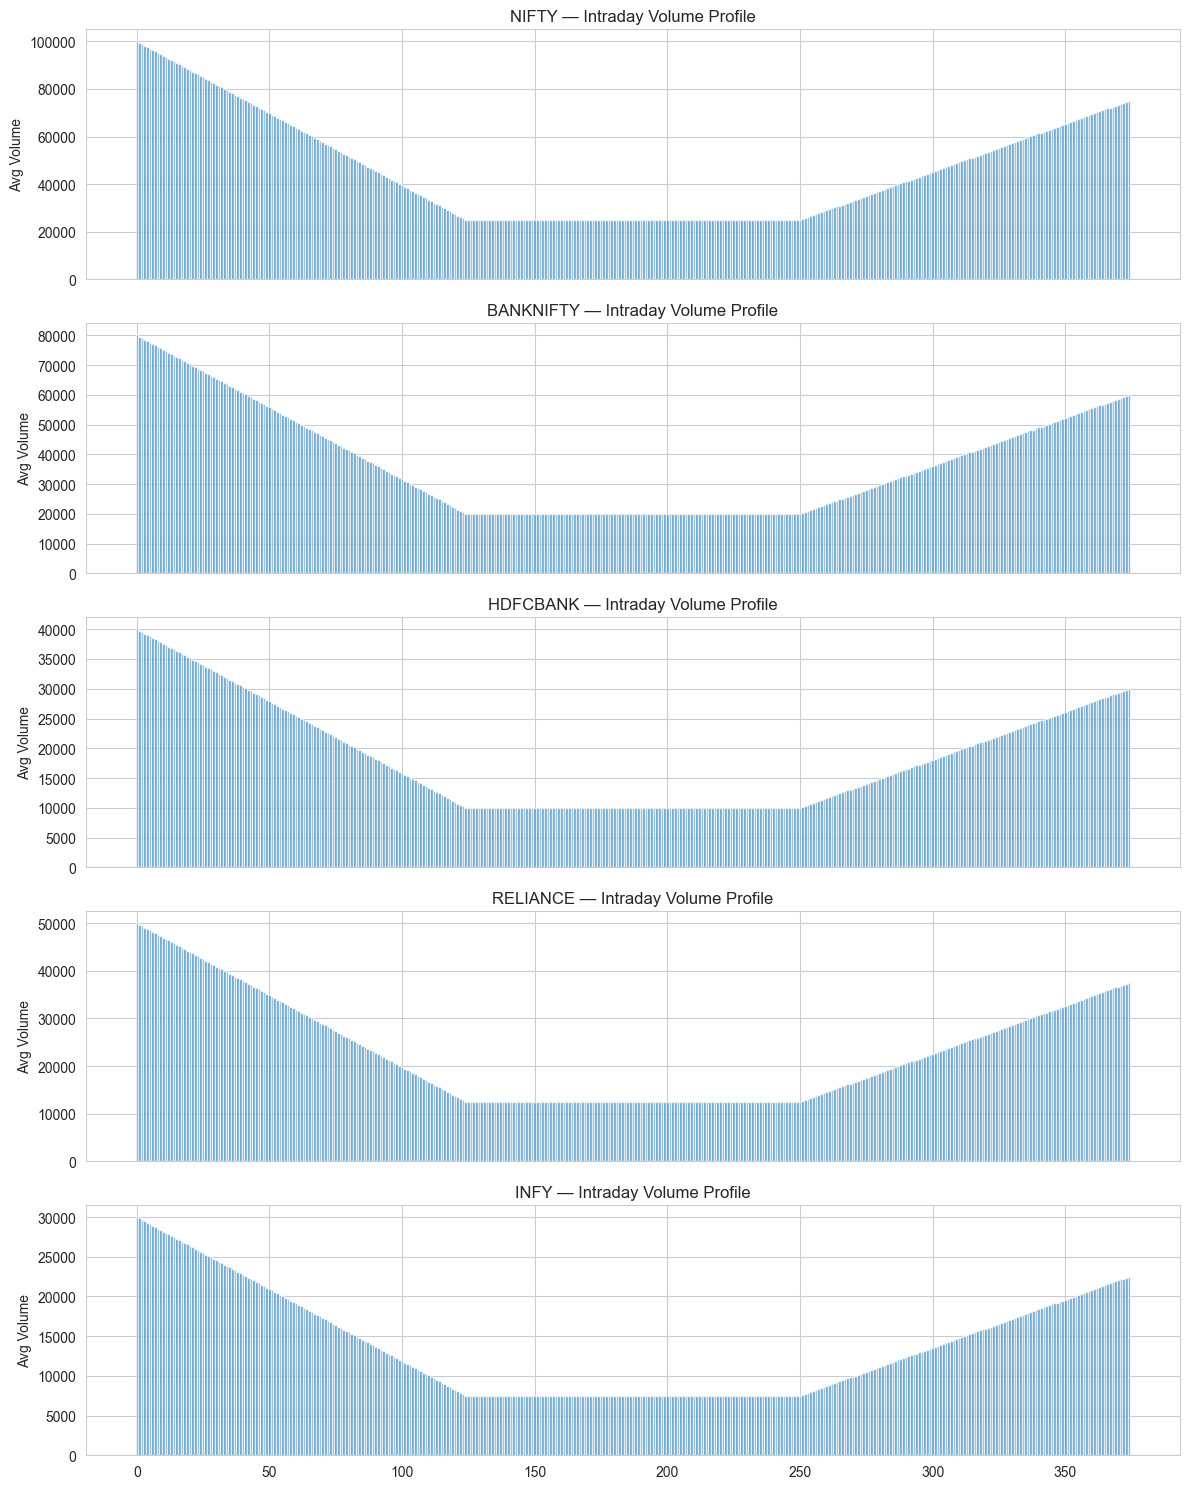

In [4]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(12, 3 * len(TICKERS)), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    df = data[ticker].copy()
    df['time'] = df.index.time
    avg_vol = df.groupby('time')['volume'].mean()
    ax.bar(range(len(avg_vol)), avg_vol.values, width=1, alpha=0.7)
    ax.set_ylabel('Avg Volume')
    ax.set_title(f'{ticker} — Intraday Volume Profile')

plt.tight_layout()
plt.savefig('../outputs/figures/intraday_volume_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Align tickers and save panel

In [5]:
panel = align_tickers(data)
print(f"Aligned panel: {panel.shape[0]:,} bars x {panel.shape[1]} columns")
print(f"Date range: {panel.index.min()} to {panel.index.max()}")

path = save_processed(panel)
print(f"Saved to {path}")

Aligned panel: 98,625 bars x 25 columns
Date range: 2024-01-02 09:15:00 to 2025-01-02 15:29:00
Saved to D:\claude projects\cross assest ofi\data\processed\panel.parquet


## 1.5 Close price series

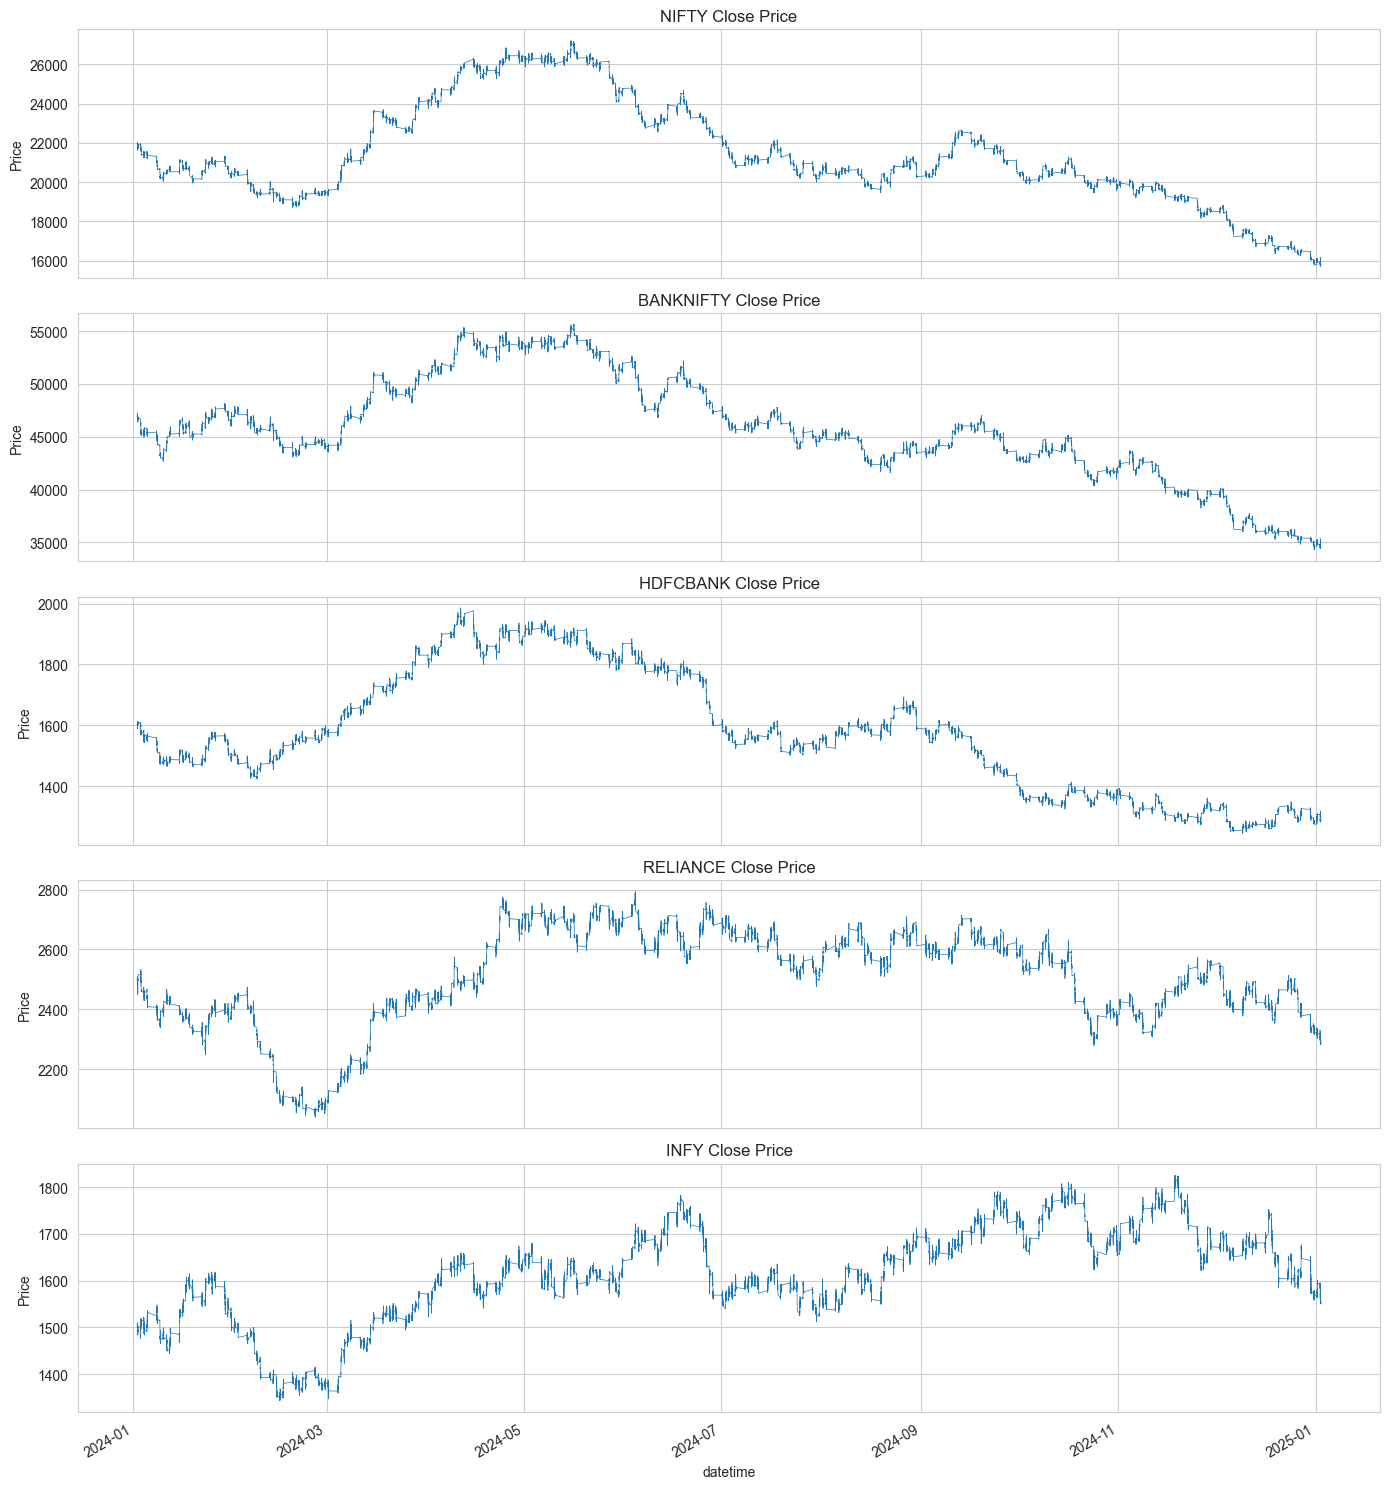

In [6]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3 * len(TICKERS)), sharex=True)

for ax, ticker in zip(axes, TICKERS):
    panel[ticker]['close'].plot(ax=ax, linewidth=0.5)
    ax.set_title(f'{ticker} Close Price')
    ax.set_ylabel('Price')

plt.tight_layout()
plt.savefig('../outputs/figures/close_prices.png', dpi=150, bbox_inches='tight')
plt.show()